In [1]:
!pip install opendatasets --quiet
import opendatasets as od
od.download("https://www.kaggle.com/datasets/mohammedalrajeh/quran-recitations-for-audio-classification")


Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: RISHIT MAHINDRU
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/mohammedalrajeh/quran-recitations-for-audio-classification


100%|██████████| 2.12G/2.12G [00:30<00:00, 75.6MB/s]


In [2]:
import torch # Main PyTorch Library
from torch import nn # Used for creating the layers and loss function
from torch.optim import Adam # Adam Optimizer
import librosa # Library that is used to read and process audio files
from torch.utils.data import Dataset, DataLoader # Dataset class and DataLoader for creating the objects
from sklearn.preprocessing import LabelEncoder # Label Encoder to encode the classes from strings to numbers
import matplotlib.pyplot as plt # Used for visualizing the images and plotting the training progress
import pandas as pd # Used to read/create dataframes (csv) and process tabular data
import numpy as np # preprocessing and numerical/mathematical operations
import os # Used to read the images path from the directory
import time # Used to calculate time for each epoch or any processing time in seconds
from skimage.transform import resize # Used to resize the images and we will use it to resize audio waves

# detect the GPU if any, if not use CPU, change "cuda" to "mps" if you have a mac
device = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
data_df = pd.read_csv("/content/quran-recitations-for-audio-classification/files_paths.csv") # Read the original csv as a dataframe

data_df['FilePath'] = '/content/quran-recitations-for-audio-classification/Dataset/' + data_df['FilePath'].str[1:] # Modify the paths in the dataframe


data_df.head() # Visualize the first 5 rows

,FilePath,Class
0,/content/quran-recitations-for-audio-classific...,Mohammed_Aluhaidan
1,/content/quran-recitations-for-audio-classific...,Mohammed_Aluhaidan
2,/content/quran-recitations-for-audio-classific...,Mohammed_Aluhaidan
3,/content/quran-recitations-for-audio-classific...,Mohammed_Aluhaidan
4,/content/quran-recitations-for-audio-classific...,Mohammed_Aluhaidan


Data Shape is:  (6687, 2)


Claases Distrubution is: 


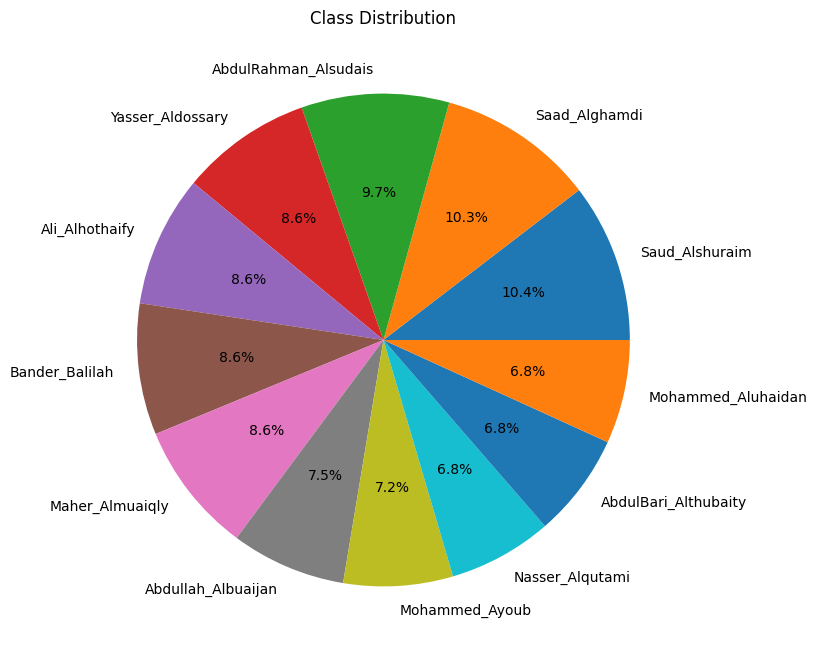

In [4]:
print("Data Shape is: ", data_df.shape) # Print the data shape (rows, columns)
print() # Empty line for better viewing

print() # Empty line for better viewing
print("Claases Distrubution is: ")

class_counts = data_df['Class'].value_counts() # Get how many data sample for each class
plt.figure(figsize=(8, 8)) # Plot a figure of 8 by 8 pixels

# we use this for plotting the how many data sample for each class
# autopct='%1.1f%%' automatically adds a label to each slice of
# the pie with its percentage of the whole, formatted to one decimal place.
plt.pie(class_counts, labels=class_counts.index, autopct='%1.1f%%')


plt.title('Class Distribution') # Add title to the whole figure

plt.show() # Visualize/show the figure - Like print()

In [5]:
label_encoder = LabelEncoder() # Defining our label encoder
data_df["Class"] = label_encoder.fit_transform(data_df["Class"]) # Class encoding

from sklearn.model_selection import train_test_split

train, temp = train_test_split(
    data_df,
    test_size=0.30,
    stratify=data_df["Class"],
    random_state=7
)

val, test = train_test_split(
    temp,
    test_size=0.50,
    stratify=temp["Class"],
    random_state=7
)


print("Training Shape: ", train.shape) # Print the Trainnig shape (rows, columns)
print("Validation Shape: ", val.shape) # Print the Validation shape (rows, columns)
print("Testing Shape: ", test.shape) # Print the Testing shape (rows, columns)

Training Shape:  (4680, 2)
Validation Shape:  (1003, 2)
Testing Shape:  (1004, 2)


In [6]:
class CustomAudioDataset(Dataset):
  def __init__(self, dataframe):
    self.dataframe = dataframe
    self.labels = torch.tensor(
    dataframe["Class"].values,
    dtype=torch.long
)
    self.audios = [torch.Tensor(self.get_spectrogram(path)).type(torch.FloatTensor) for path in dataframe['FilePath']]

  def __len__(self):
    return self.dataframe.shape[0]

  def __getitem__(self, idx):
    img_path = self.dataframe.iloc[idx, 0]
    label = self.labels[idx]

    audio = self.audios[idx].unsqueeze(0)
    return audio, label

  def get_spectrogram(self, file_path):
    sr = 22050 # Set the sample rate of the audio file
    duration = 5 # Set the duration of the audio files

    # Set the size of the spectrogram images
    img_height = 128
    img_width = 256

    # Load the audio file
    signal, sr = librosa.load(file_path, sr=22050, duration=duration)

    # Compute the spectrogram
    spec = librosa.feature.melspectrogram(y=signal, sr=sr, n_fft=2048, hop_length=512, n_mels=128)

    spec_db = librosa.power_to_db(spec, ref=np.max)

    spec_db = (spec_db - np.mean(spec_db)) / (np.std(spec_db) + 1e-8)

    spec_resized = librosa.util.fix_length(
        spec_db,
        size=duration * sr // 512 + 1
    )

    spec_resized = resize(
        spec_resized,
        (img_height, img_width),
        anti_aliasing=True
    )

    return spec_resized.astype(np.float32)

In [7]:
train_dataset = CustomAudioDataset(dataframe=train)
val_dataset = CustomAudioDataset(dataframe=val)
test_dataset = CustomAudioDataset(dataframe=test)

In [8]:
LR = 1e-4
BATCH_SIZE = 16
EPOCHS = 25

In [9]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

In [10]:
class Net(nn.Module):
  def __init__(self):
    super().__init__()

    self.conv1 = nn.Conv2d(1, 16, kernel_size = 3, padding = 1) # First Convolution layer
    self.bn1 = nn.BatchNorm2d(16)
    self.conv2 = nn.Conv2d(16, 32, kernel_size = 3, stride = 1, padding = 1) # Second Convolution layer
    self.bn2 = nn.BatchNorm2d(32)
    self.conv3 = nn.Conv2d(32, 64, kernel_size = 3, stride = 1, padding = 1) # Third Convolution layer
    self.bn3 = nn.BatchNorm2d(64)
    self.pooling = nn.MaxPool2d(2,2) # The pooling layer, we will be using the same layer after each conv2d.
    self.relu = nn.ReLU() # ReLU Activation function
    self.linear1 = nn.Linear((64 * 16 * 32), 4096) # Traditional Dense (Linear)
    self.linear2 = nn.Linear(4096, 1024) # Traditional Dense (Linear)
    self.linear4 = nn.Linear(1024, 512) # Traditional Dense (Linear)
    self.output = nn.Linear(512, len(data_df['Class'].unique())) # Output Linear Layer

    self.dropout = nn.Dropout(0.5)

  def forward(self, x):
    x = self.conv1(x)
    x = self.bn1(x)
    x = self.relu(x)
    x = self.pooling(x)
    x = self.dropout(x)
    x = self.conv2(x)
    x = self.bn2(x)
    x = self.relu(x)
    x = self.pooling(x)
    x = self.dropout(x)
    x = self.conv3(x)
    x = self.bn3(x)
    x = self.relu(x)
    x = self.pooling(x)
    x = self.dropout(x)
    x = x.view(x.size(0), -1)
    x = self.linear1(x)
    x = self.dropout(x)
    x = self.linear2(x)
    x = self.dropout(x)
    x = self.linear4(x)
    x = self.dropout(x)
    x = self.output(x)
    return x

model = Net().to(device) # Create an instance of the model and move it to the GPU Device


print(model)

Net(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pooling): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (linear1): Linear(in_features=32768, out_features=4096, bias=True)
  (linear2): Linear(in_features=4096, out_features=1024, bias=True)
  (linear4): Linear(in_features=1024, out_features=512, bias=True)
  (output): Linear(in_features=512, out_features=12, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)


In [11]:
from torchsummary import summary # Visualize the model layers and number of parameters
summary(model, (1, 128, 256)) # Visualize the model layers by taking the input size expected (-1 in the output will be replaced by the batch size in training)


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 16, 128, 256]             160
       BatchNorm2d-2         [-1, 16, 128, 256]              32
              ReLU-3         [-1, 16, 128, 256]               0
         MaxPool2d-4          [-1, 16, 64, 128]               0
           Dropout-5          [-1, 16, 64, 128]               0
            Conv2d-6          [-1, 32, 64, 128]           4,640
       BatchNorm2d-7          [-1, 32, 64, 128]              64
              ReLU-8          [-1, 32, 64, 128]               0
         MaxPool2d-9           [-1, 32, 32, 64]               0
          Dropout-10           [-1, 32, 32, 64]               0
           Conv2d-11           [-1, 64, 32, 64]          18,496
      BatchNorm2d-12           [-1, 64, 32, 64]             128
             ReLU-13           [-1, 64, 32, 64]               0
        MaxPool2d-14           [-1, 64,

In [12]:
criterion = nn.CrossEntropyLoss() # Cross Entropy Loss
optimizer = Adam(model.parameters(), lr=LR) # Adam optimizer
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

In [13]:
total_loss_train_plot = [] # Empty list to be filled with train loss after each epoch
total_loss_validation_plot = [] # Empty list to be filled with validation loss after each epoch
total_acc_train_plot = [] # Empty list to be filled with train accuracy after each epoch
total_acc_validation_plot = [] # Empty list to be filled with validation accuracy after each epoch
best_accuracy = 0
patience = 5
counter = 0


for epoch in range(EPOCHS):
  model.train()
  start_time = time.time() # We use this to calculate the time of each epoch, it starts a counter once called
  total_acc_train = 0
  total_loss_train = 0
  total_loss_val = 0
  total_acc_val = 0

  for inputs, labels in train_loader:
    inputs = inputs.to(device)
    labels = labels.to(device)
    outputs = model(inputs)
    train_loss = criterion(outputs, labels)
    total_loss_train += train_loss.item()
    train_loss.backward()

    train_acc = (torch.argmax(outputs, axis = 1) == labels).sum().item()
    total_acc_train += train_acc
    optimizer.step()
    optimizer.zero_grad()

  model.eval()

  with torch.no_grad():
    for inputs, labels in val_loader:
      inputs = inputs.to(device)
      labels = labels.to(device)
      outputs = model(inputs)
      val_loss = criterion(outputs, labels)
      total_loss_val += val_loss.item()

      val_acc = (torch.argmax(outputs, axis = 1) == labels).sum().item()
      total_acc_val += val_acc

  total_loss_train_plot.append(round(total_loss_train/1000, 4))
  total_loss_validation_plot.append(round(total_loss_val/1000, 4))
  total_acc_train_plot.append(round(total_acc_train/(train_dataset.__len__())*100, 4))
  total_acc_validation_plot.append(round(total_acc_val/(val_dataset.__len__())*100, 4))
  val_acc = total_acc_val / len(val_dataset)
  scheduler.step(val_acc)
  if val_acc > best_accuracy:
    best_accuracy = val_acc
    counter = 0
    torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "epoch": epoch,
    "best_accuracy": best_accuracy
    }, "best_model.pth")

  else:
    counter += 1

  if counter >= patience:
    print("Early stopping...")
    break
  epoch_string = f"""
                  Epoch: {epoch+1}/{EPOCHS},
                  Train Loss: {round(total_loss_train/100, 4)},
                  Train Accuracy: {round((total_acc_train/train_dataset.__len__() * 100), 4)},
                  Validation Loss: {round(total_loss_val/100, 4)},
                  Validation Accuracy: {round((total_acc_val/val_dataset.__len__() * 100), 4)}
                  """
  print(epoch_string)
  print("="*30)

Best model saved!

                  Epoch: 1/25,
                  Train Loss: 13.2417,
                  Train Accuracy: 23.141,
                  Validation Loss: 1.0531,
                  Validation Accuracy: 39.5813
                  
Best model saved!

                  Epoch: 2/25,
                  Train Loss: 7.1687,
                  Train Accuracy: 47.3504,
                  Validation Loss: 0.4967,
                  Validation Accuracy: 73.7787
                  
Best model saved!

                  Epoch: 3/25,
                  Train Loss: 5.3261,
                  Train Accuracy: 61.5812,
                  Validation Loss: 0.4135,
                  Validation Accuracy: 78.0658
                  
Best model saved!

                  Epoch: 4/25,
                  Train Loss: 4.3632,
                  Train Accuracy: 68.5256,
                  Validation Loss: 0.299,
                  Validation Accuracy: 83.9482
                  
Best model saved!

                  Epoc

In [14]:
with torch.no_grad():
  total_loss_test = 0
  total_acc_test = 0
  for indx, (input, labels) in enumerate(test_loader):
    input = input.to(device)
    labels = labels.to(device)

    prediction = model(input)

    acc = (torch.argmax(prediction, axis = 1) == labels).sum().item()
    total_acc_test += acc

print(f"Accuracy Score is: {round((total_acc_test/test_dataset.__len__())*100, 2)}%")

Accuracy Score is: 95.02%


              precision    recall  f1-score   support

           0       1.00      0.96      0.98        68
           1       1.00      1.00      1.00        97
           2       0.79      1.00      0.88        75
           3       0.91      1.00      0.95        87
           4       0.91      0.94      0.93        87
           5       0.98      0.99      0.98        87
           6       0.98      0.81      0.89        68
           7       1.00      0.93      0.96        72
           8       0.97      0.94      0.96        68
           9       0.98      0.99      0.99       103
          10       0.99      0.91      0.95       105
          11       0.94      0.90      0.92        87

    accuracy                           0.95      1004
   macro avg       0.95      0.95      0.95      1004
weighted avg       0.95      0.95      0.95      1004



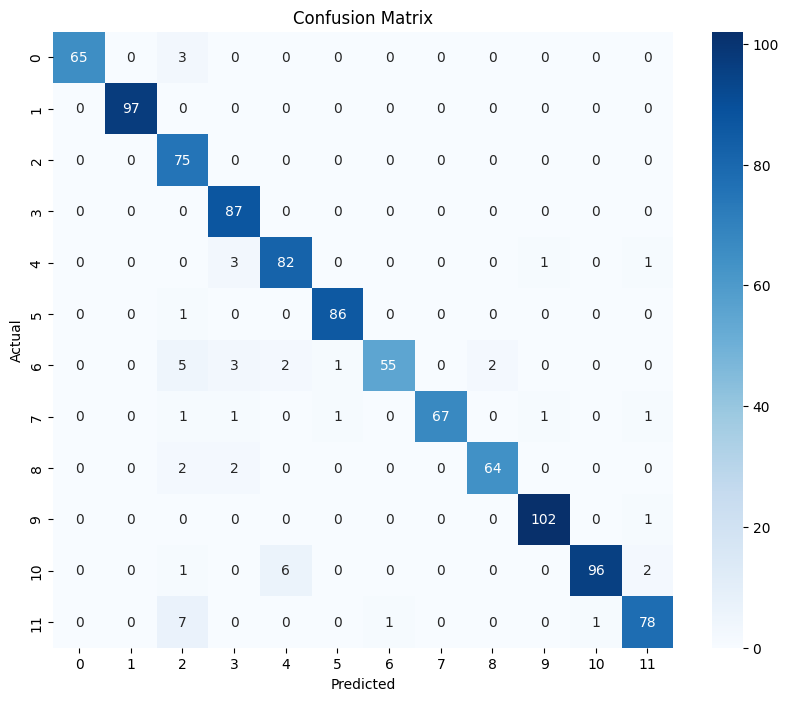

In [15]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

predictions = []
true_labels = []

model.eval()

with torch.no_grad():

    for inputs, labels in test_loader:

        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)

        preds = torch.argmax(outputs, dim=1)

        predictions.extend(preds.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

print(classification_report(true_labels, predictions))

cm = confusion_matrix(true_labels, predictions)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

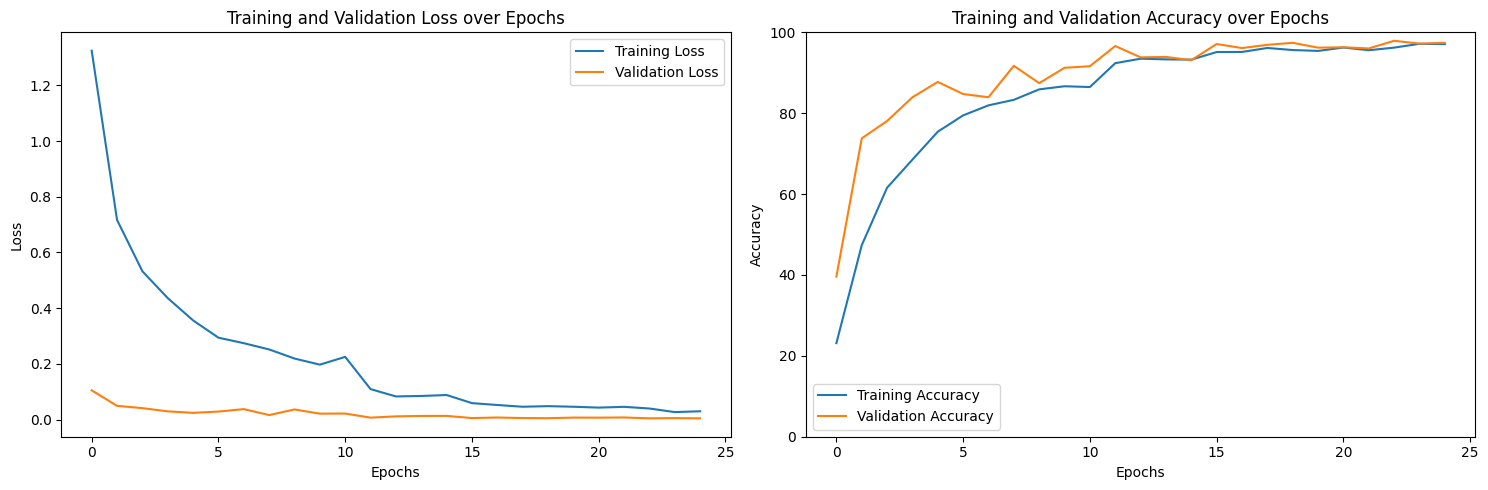

In [16]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

axs[0].plot(total_loss_train_plot, label='Training Loss')
axs[0].plot(total_loss_validation_plot, label='Validation Loss')
axs[0].set_title('Training and Validation Loss over Epochs')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[1].set_ylim([0, 2])
axs[0].legend()

axs[1].plot(total_acc_train_plot, label='Training Accuracy')
axs[1].plot(total_acc_validation_plot, label='Validation Accuracy')
axs[1].set_title('Training and Validation Accuracy over Epochs')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].set_ylim([0, 100])
axs[1].legend()

plt.tight_layout()

plt.show()